# 02 — Supervisionado: Preferência

## Bloco 1 — Contexto e pergunta

No contexto da plataforma de streaming, a primeira formulação que examinamos é a mais direta:

**O usuário vai gostar deste filme?**

Essa pergunta tem uma característica central: o dataset já contém a resposta. Cada linha de `ratings.csv` registra a nota que um usuário atribuiu a um filme. A nota é o sinal explícito de aprovação ou rejeição — ela é o **rótulo**.

A transformação é direta:

| Nota (`rating`) | Rótulo (`gostou`) | Interpretação |
|---|---|---|
| ≥ 4,0 | 1 | O usuário gostou |
| < 4,0 | 0 | O usuário não gostou |

Esse é o ponto de partida do aprendizado supervisionado: existem exemplos com respostas conhecidas e o objetivo é aprender a prever a resposta para novos pares (usuário, filme) ainda não vistos.

## Informações do notebook

| Item | Detalhe |
|---|---|
| **Aula** | Aula 01 — Paradigmas de ML com MovieLens |
| **Notebook** | 02 — Supervisionado: Preferência |
| **Seções** | 1.2 — Aprendizado supervisionado |
| **Tempo de leitura** | 12 min |
| **Tempo de execução (padrão)** | 5 min |
| **Exercícios** | 3 questões de autoavaliação |

### Pré-requisitos

- **Notebooks anteriores:** `01_contexto_movielens.ipynb` — exploração do MovieLens e download dos dados.
- **Conceitos:** noção de rótulo, features e predição.

### Competências para o Desafio Final

- Construir um preditor de preferência usuário-filme como componente de filtragem do sistema de recomendação.
- Interpretar probabilidade estimada e métricas de classificação em contexto de recomendação.
- Reconhecer as limitações do supervisionado para decisão sequencial.

### Recapitulando

No notebook anterior exploramos o dataset **MovieLens**: 100.836 avaliações, 610 usuários, 9.724 filmes. A nota (0,5–5,0) é o sinal central do curso — neste notebook ela se torna um **rótulo** binário (`gostou = nota ≥ 4`). A limitação central do contexto: a nota só existe para pares (usuário, filme) já avaliados.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))

import rl_utils
rl_utils.info_versoes()
rl_utils.configurar_matplotlib()
rl_utils.definir_seeds(42)

Biblioteca           Versão
--------------------------------
gymnasium            1.0.0


torch                2.11.0+cpu
numpy                2.4.2
matplotlib           3.10.8
pandas               3.0.1


scikit-learn         1.8.0


## Bloco 2 — Mini teoria

### Estrutura do supervisionado: pares (x, y)

No supervisionado, cada observação de treino é um par composto por:

- **x** (entrada): vetor de características que descrevem o usuário e o filme.
- **y** (saída): o rótulo — a resposta correta para aquele exemplo.

Neste problema, as entradas serão estatísticas derivadas do histórico de avaliações:

| Feature | Descrição |
|---|---|
| `media_usuario` | Média das notas atribuídas pelo usuário em toda a sua história |
| `media_filme` | Média das notas recebidas pelo filme de todos os usuários |
| `qtd_avaliacoes_usuario` | Quantidade total de filmes avaliados pelo usuário |

### Função de perda e ajuste do modelo

O treinamento busca parâmetros que minimizem o erro entre a previsão `ŷ` e o rótulo real `y`. Na regressão logística, isso equivale a maximizar a probabilidade de cada rótulo observado dado as features. A cada iteração, os pesos são ajustados na direção que reduz o erro médio sobre os exemplos de treino.

O resultado do treino é um modelo que, para qualquer par (usuário, filme) com features conhecidas, estima a probabilidade de `gostou = 1`.

### Limitação estrutural

O supervisionado responde bem a perguntas de previsão pontual com rótulo explícito. Ele não modela o efeito de uma *sequência* de recomendações: a escolha de recomendar filme A hoje pode influenciar o que o usuário vai querer depois — e essa dinâmica de consequências futuras não está representada nos pares (x, y).

## Exemplo mínimo: preferência binária em 5 avaliações

Antes do dataset MovieLens completo, cinco pares fictícios (usuário, filme) com notas conhecidas mostram como o modelo converte médias em rótulo e aprende a separar gostos. Nenhuma biblioteca de ML é necessária — apenas aritmética de médias e uma regra de decisão simples.

In [2]:
import numpy as np

# 5 pares (media_usuario, media_filme) com rótulo real
exemplos = [
    (4.2, 4.0, 1),  # usuário exigente + filme bem avaliado → gostou
    (2.8, 2.5, 0),  # usuário com notas baixas + filme fraco → não gostou
    (3.9, 4.5, 1),  # usuário médio + filme muito bom → gostou
    (4.5, 2.1, 0),  # usuário rigoroso + filme fraco → não gostou
    (3.1, 3.9, 1),  # usuário casual + filme razoável → gostou
]

print("Pares fictícios: (media_usuario, media_filme) → gostou")
print(f"\n{'media_usuario':>15} {'media_filme':>13} {'gostou':>8}")
print("-" * 40)
for mu, mf, g in exemplos:
    print(f"{mu:15.1f} {mf:13.1f} {g:8d}")

# Regra simples: média das médias >= 3.5 → prediz gostou=1
LIMIAR = 3.5
print(f"\nRegra simples: (media_usuario + media_filme) / 2 >= {LIMIAR} → prediz gostou=1")
print()
corretos = 0
for mu, mf, real in exemplos:
    media = (mu + mf) / 2
    pred  = 1 if media >= LIMIAR else 0
    ok    = pred == real
    corretos += ok
    print(f"  média={media:.2f} → pred={pred}, real={real}  {'✓' if ok else '✗'}")

print(f"\nAcurácia da regra simples: {corretos}/{len(exemplos)} = {corretos/len(exemplos):.0%}")
print("A regressão logística aprende um limiar ótimo — não fixo — usando todos os exemplos de treino.")

Pares fictícios: (media_usuario, media_filme) → gostou

  media_usuario   media_filme   gostou
----------------------------------------
            4.2           4.0        1
            2.8           2.5        0
            3.9           4.5        1
            4.5           2.1        0
            3.1           3.9        1

Regra simples: (media_usuario + media_filme) / 2 >= 3.5 → prediz gostou=1

  média=4.10 → pred=1, real=1  ✓
  média=2.65 → pred=0, real=0  ✓
  média=4.20 → pred=1, real=1  ✓
  média=3.30 → pred=0, real=0  ✓
  média=3.50 → pred=1, real=1  ✓

Acurácia da regra simples: 5/5 = 100%
A regressão logística aprende um limiar ótimo — não fixo — usando todos os exemplos de treino.


## Autoavaliação

<details>
<summary>Pergunta 1: Por que o modelo supervisionado não é suficiente para decidir qual filme recomendar em tempo real?</summary>

**Resposta:** Porque o supervisionado estima uma probabilidade de satisfação para pares (usuário, filme) já formados — não escolhe *qual* filme mostrar. Ranquear candidatos pela probabilidade de gostar é uma heurística útil, mas não modela a sequência de recomendações: a escolha de hoje afeta preferências futuras, e essa dinâmica temporal não está no par (x, y) de treino.

**Por quê:** O supervisionado é um preditor estático. A recomendação sequencial é um problema de decisão com consequências futuras — domínio do Aprendizado por Reforço.

</details>

<details>
<summary>Pergunta 2: Por que é necessário aplicar StandardScaler antes de treinar a regressão logística?</summary>

**Resposta:** A regressão logística é sensível à escala das features. A feature `qtd_avaliacoes_usuario` pode ter magnitude 100–2000, enquanto `media_usuario` e `media_filme` ficam entre 0 e 5. Sem normalização, o gradiente é dominado pela feature de maior magnitude, dificultando a convergência. O StandardScaler padroniza cada feature para média 0 e desvio padrão 1, colocando todas na mesma escala.

**Por quê:** O mesmo coeficiente de regularização se aplica a todas as features após normalização. Sem isso, a regularização favorece desproporcionalmente features com menor magnitude.

</details>

<details>
<summary>Pergunta 3: O que o histograma de probabilidades por classe real revela sobre o modelo?</summary>

**Resposta:** Um bom modelo de classificação deve produzir distribuições separadas: a distribuição de `prob_gostou` para exemplos com `gostou=1` deve estar deslocada para a direita (perto de 1.0), e para `gostou=0` para a esquerda (perto de 0.0). Se as duas distribuições se sobrepõem muito, o modelo não discrimina bem — e a acurácia pode ser enganosa, especialmente se houver desbalanceamento entre as classes.

**Por quê:** A acurácia mede apenas o ponto de corte em 0.5 — o histograma mostra a qualidade da estimativa probabilística em toda a faixa [0, 1].

</details>

## Mapeamento para o Desafio Final

| Competência | Quando usar no Desafio Final |
|---|---|
| Prever P(gostou) com regressão logística | Componente de *ranqueamento*: estimar probabilidade de satisfação para pares (usuário, item) candidatos |
| Interpretar probabilidade estimada e histograma por classe | Avaliar se o preditor discrimina bem antes de integrá-lo à pipeline de decisão |
| Reconhecer limitações do supervisionado para decisão sequencial | Contextualizar quando o preditor é insuficiente e o agente de RL é necessário |
| Identificar o problema de cold start | Explicar limitações para usuários novos ou filmes sem histórico de avaliações |

**Regra prática:** o preditor supervisionado é o *pré-filtro* no Desafio Final — ele reduz o espaço de candidatos de milhares de itens para dezenas. A decisão final sobre qual item recomendar pertence ao agente de RL (Aulas 02–04).

## Bloco 3 — Código didático mínimo

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RATINGS_PATH = 'data/movielens/ratings.csv'
SEED = 42

try:
    ratings = pd.read_csv(RATINGS_PATH)
except FileNotFoundError:
    raise FileNotFoundError(
        'ratings.csv não encontrado. '
        'Execute o notebook 01_contexto_movielens.ipynb para preparar os dados.'
    )

# Amostragem controlada para execução ágil em aula gravada
ratings = ratings.sample(n=min(30_000, len(ratings)), random_state=SEED).copy()

# Variável alvo: nota >= 4 → gostou (1), nota < 4 → não gostou (0)
ratings['gostou'] = (ratings['rating'] >= 4).astype(int)

dist = (
    ratings['gostou']
    .value_counts()
    .rename({0: 'não gostou (0)', 1: 'gostou (1)'})
    .rename_axis('rótulo')
    .reset_index(name='quantidade')
)
dist['proporção'] = (dist['quantidade'] / dist['quantidade'].sum()).round(3)

print(f'Avaliações carregadas: {len(ratings):,}')
print('\nDistribuição do rótulo gostou:')
display(dist)

Avaliações carregadas: 30,000

Distribuição do rótulo gostou:


,rótulo,quantidade,proporção
0,não gostou (0),15637,0.521
1,gostou (1),14363,0.479


In [4]:
# Features por usuário: média de notas e quantidade de avaliações
user_stats = ratings.groupby('userId').agg(
    media_usuario=('rating', 'mean'),
    qtd_avaliacoes_usuario=('rating', 'count'),
).reset_index()

# Features por filme: média de notas recebidas
film_stats = ratings.groupby('movieId').agg(
    media_filme=('rating', 'mean'),
).reset_index()

# Dataset com features e rótulo
df = (
    ratings[['userId', 'movieId', 'rating', 'gostou']]
    .merge(user_stats, on='userId')
    .merge(film_stats, on='movieId')
)

FEATURES = ['media_usuario', 'media_filme', 'qtd_avaliacoes_usuario']

print('Amostra do dataset com features e rótulo:')
display(df[FEATURES + ['gostou']].head(8))
print(f'\nTotal de exemplos: {len(df):,}')

Amostra do dataset com features e rótulo:


,media_usuario,media_filme,qtd_avaliacoes_usuario,gostou
0,3.664557,4.500000,79,1
1,3.166667,3.447368,342,0
2,2.638268,3.500000,716,0
3,3.640000,3.500000,125,1
4,2.650000,4.018519,20,1
5,3.710000,2.500000,100,1
6,3.680556,3.796296,72,0
7,3.090909,4.265625,11,1



Total de exemplos: 30,000


In [5]:
X = df[FEATURES].values
y = df['gostou'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Normalização: regressão logística é sensível à escala das features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

modelo = LogisticRegression(max_iter=300, random_state=SEED)
modelo.fit(X_train_sc, y_train)

acuracia = modelo.score(X_test_sc, y_test)

print(f'Exemplos de treino : {len(X_train):,}')
print(f'Exemplos de teste  : {len(X_test):,}')
print(f'\nAcurácia no conjunto de teste: {acuracia:.4f}  ({acuracia * 100:.1f}%)')

Exemplos de treino : 24,000
Exemplos de teste  : 6,000

Acurácia no conjunto de teste: 0.7580  (75.8%)


Exemplos de previsão — rótulo real vs. previsão do modelo:


,media_usuario,media_filme,qtd_avaliacoes_usuario,gostou,prob_gostou,pred_gostou,correto
0,3.134615,3.184211,26,0,0.158,0,True
1,3.083333,3.900000,198,1,0.480,0,False
2,3.812057,4.750000,141,1,0.962,1,True
3,3.255319,3.548387,141,1,0.357,0,False
4,3.934426,4.142857,61,1,0.883,1,True


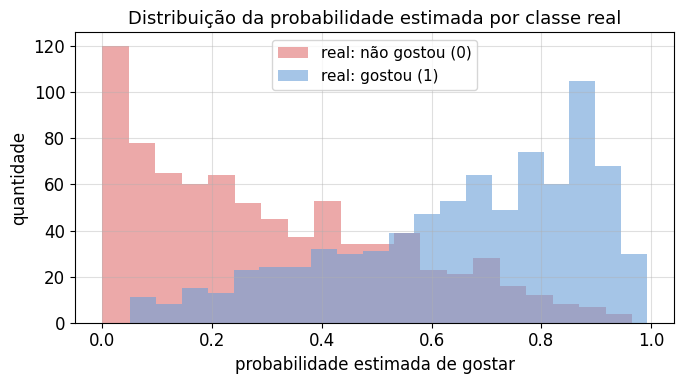

In [6]:
# 5 exemplos: rótulo real vs. previsão do modelo
amostra = df[FEATURES + ['gostou']].sample(5, random_state=SEED).copy()
X_am    = scaler.transform(amostra[FEATURES].values)

amostra['prob_gostou'] = modelo.predict_proba(X_am)[:, 1].round(3)
amostra['pred_gostou'] = modelo.predict(X_am)
amostra['correto']     = (amostra['pred_gostou'] == amostra['gostou'])

print('Exemplos de previsão — rótulo real vs. previsão do modelo:')
display(amostra.reset_index(drop=True))

# Histograma: distribuição de prob_gostou separada por classe real
fig, ax = plt.subplots(figsize=(7, 4))
for rotulo, cor, nome in [(0, '#e07070', 'não gostou (0)'), (1, '#6a9fd8', 'gostou (1)')]:
    subset  = df[df['gostou'] == rotulo].sample(800, random_state=SEED)
    probs   = modelo.predict_proba(scaler.transform(subset[FEATURES].values))[:, 1]
    ax.hist(probs, bins=20, alpha=0.6, color=cor, label=f'real: {nome}')

ax.set_xlabel('probabilidade estimada de gostar')
ax.set_ylabel('quantidade')
ax.set_title('Distribuição da probabilidade estimada por classe real')
ax.legend()
plt.tight_layout()
plt.show()

## Glossário — termos introduzidos neste notebook

| Termo (EN) | Tradução (PT) | Descrição |
|---|---|---|
| label | rótulo | Valor-alvo (`gostou`) associado a cada exemplo de treino. |
| logistic regression | regressão logística | Modelo linear que estima a probabilidade de pertencimento a uma classe. |
| train-test split | divisão treino-teste | Separação dos dados em conjunto de treino e conjunto de avaliação independente. |
| accuracy | acurácia | Proporção de previsões corretas em relação ao total de exemplos avaliados. |
| class imbalance | desbalanceamento de classes | Situação em que uma classe do rótulo é muito mais frequente que a outra. |

> Glossário completo do curso: [docs/glossario.md](../../docs/glossario.md)

## Bloco 4 — Interpretação pedagógica

### O que a acurácia mede neste contexto

A acurácia reporta a proporção de previsões corretas sobre o conjunto de teste — exemplos que o modelo nunca viu durante o treino. Um valor de 70–75% indica que, em cerca de 3 a cada 4 pares (usuário, filme) novos, o modelo acerta se o usuário vai gostar ou não.

Esse número deve ser lido com cuidado: o rótulo `gostou` é majoritário no dataset (notas tendem a ser altas), portanto um preditor trivial que sempre responde "gostou" já obteria acurácia não negligenciável. O histograma de probabilidades estimadas por classe real é mais informativo: se o modelo discrimina bem, a distribuição de `prob_gostou` deve ser deslocada para a direita quando `gostou = 1` e para a esquerda quando `gostou = 0`.

### O modelo aprende com exemplos respondidos

O mecanismo central do supervisionado é que **o sinal de aprendizado existe antes do treinamento**: cada par (usuário, filme) já vem com a nota. O modelo ajusta seus pesos para reproduzir esse padrão em novos exemplos.

Esse mecanismo contrasta com o Aprendizado por Reforço:

| Aspecto | Supervisionado | Aprendizado por Reforço |
|---|---|---|
| Sinal de aprendizado | Rótulo pré-existente no dataset | Recompensa recebida após a ação |
| Momento do aprendizado | Treinamento em lote com histórico | Interação contínua com o ambiente |
| Objetivo de otimização | Minimizar erro de previsão | Maximizar retorno cumulativo |

### Utilidade e alcance para recomendação

Um modelo supervisionado pode estimar, para qualquer par (usuário, filme), a probabilidade de gostar. Isso é útil para ranquear candidatos e filtrar itens com baixa probabilidade. No entanto, o modelo não decide *qual* item mostrar, não considera que a escolha de hoje afeta preferências futuras, e depende de rótulos históricos — o que o torna limitado para usuários novos ou filmes sem avaliações.

## Bloco 5 — Limites e transição

### O que o supervisionado não responde

O paradigma supervisionado é adequado para previsão pontual com rótulo explícito. O problema de recomendação, porém, tem dimensões que ele não cobre:

- **"Que tipos de usuários ou filmes existem?"** — O supervisionado classifica cada par individualmente; não agrupa usuários por perfil de consumo nem descobre estrutura latente no catálogo. Para isso, é necessário um paradigma que trabalhe sem rótulo.
- **"Qual filme recomendar agora?"** — Ranquear candidatos pela probabilidade de gostar é uma heurística, não uma política de decisão. O efeito de uma sequência de recomendações — recomendar A hoje e B amanhã, observando como o usuário responde — está fora do escopo do par (x, y).

Há também uma limitação de dados: o supervisionado depende de rótulos, e rótulos exigem avaliações explícitas. Usuários novos e filmes sem histórico geram o problema de *cold start* — não há sinal suficiente para treinar ou prever.

### O que vem a seguir

O próximo notebook aborda a segunda formulação:

**Que tipos de usuários ou filmes existem?**

Essa pergunta não tem resposta correta no dataset. Ela é respondida pelo aprendizado não supervisionado, que descobre estrutura sem rótulo explícito.

## Leituras e referências

- Hastie, T.; Tibshirani, R.; Friedman, J. *The Elements of Statistical Learning*. Springer, 2009. Cap. 4 (Regressão Logística).
- Pedregosa, F. et al. Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830, 2011. Disponível em: https://scikit-learn.org (acesso em 2026-03-07).
- MovieLens (GroupLens): https://grouplens.org/datasets/movielens/ (acesso em 2026-03-07).
- Roteiro da Aula 01, Vídeo 2: `roteiros/Aula 01 - Roteiro video aula.md`.